# Credit Card Fraud Detection Machine Learning Project
This notebook implements a comprehensive fraud detection model using Logistic Regression and Random Forest classifiers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

## Step 1: Load and Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset shape:", df.shape)

First 5 rows of the dataset:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

   

## Step 2: Check for Missing Values

In [3]:
# Check for missing values
print("Missing values in the dataset:")
missing_values = df.isnull().sum()
print(missing_values)
print("\nTotal missing values:", missing_values.sum())

Missing values in the dataset:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values: 0


## Step 3: Visualize Class Distribution (Fraud vs Normal Transactions)

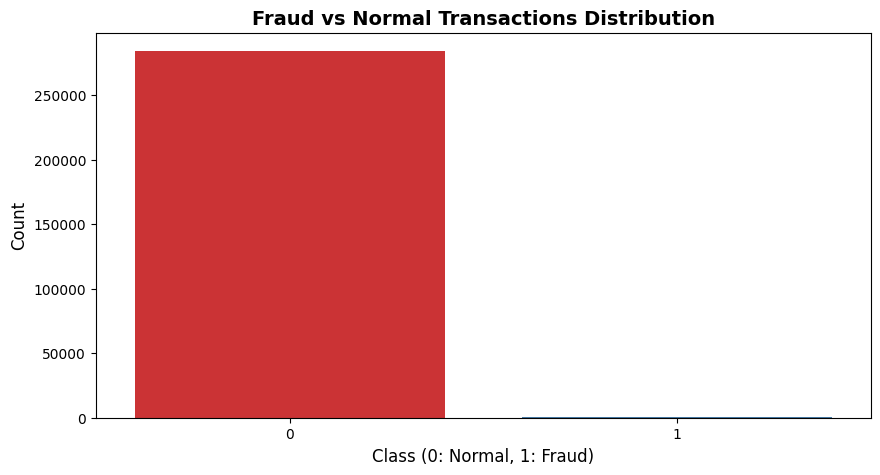


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution (%):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [4]:
# Create a countplot to visualize fraud vs normal transactions
plt.figure(figsize=(10, 5))
sns.countplot(x='Class', data=df, palette='Set1')
plt.title('Fraud vs Normal Transactions Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class (0: Normal, 1: Fraud)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# Print class distribution
print("\nClass distribution:")
print(df['Class'].value_counts())
print("\nClass distribution (%):")
print(df['Class'].value_counts(normalize=True) * 100)

## Step 4: Reduce Dataset Size Using Sampling (50,000 rows)

In [5]:
# Randomly sample 50,000 rows for faster training
sample_size = 50000
df_sampled = df.sample(n=sample_size, random_state=42)

print(f"Original dataset size: {df.shape[0]}")
print(f"Sampled dataset size: {df_sampled.shape[0]}")
print(f"Reduction: {100 * (1 - df_sampled.shape[0] / df.shape[0]):.2f}%")

Original dataset size: 284807
Sampled dataset size: 50000
Reduction: 82.44%


## Step 5: Split Dataset into Features (X) and Target (y)

In [6]:
# Separate features and target variable
X = df_sampled.drop('Class', axis=1)  # Features (all columns except Class)
y = df_sampled['Class']               # Target variable (Class: 0=Normal, 1=Fraud)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.head())

Features shape: (50000, 30)
Target shape: (50000,)

Features:
            Time         V1        V2         V3        V4         V5  \
43428    41505.0 -16.526507  8.584972 -18.649853  9.505594 -13.793819   
49906    44261.0   0.339812 -2.743745  -0.134070 -1.385729  -1.451413   
29474    35484.0   1.399590 -0.590701   0.168619 -1.029950  -0.539806   
276481  167123.0  -0.432071  1.647895  -1.669361 -0.349504   0.785785   
278846  168473.0   2.014160 -0.137394  -1.015839  0.327269  -0.182179   

              V6         V7        V8        V9  ...       V20       V21  \
43428  -2.832404 -16.701694  7.517344 -8.507059  ... -1.514923  1.190739   
49906   1.015887  -0.524379  0.224060  0.899746  ...  0.506044 -0.213436   
29474   0.040444  -0.712567  0.002299 -0.971747  ...  0.212877  0.102398   
276481 -0.630647   0.276990  0.586025 -0.484715  ... -0.244633  0.358932   
278846 -0.956571   0.043241 -0.160746  0.363241  ... -0.255293 -0.238644   

             V22       V23       V24      

## Step 6: Train-Test Split (80% train, 20% test)

In [7]:
# Split dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Training set size: 40000
Testing set size: 10000

X_train shape: (40000, 30)
X_test shape: (10000, 30)
y_train shape: (40000,)
y_test shape: (10000,)


## Step 7: Train Logistic Regression Model

In [8]:
# Train Logistic Regression model
print("Training Logistic Regression model...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
print("Logistic Regression model trained successfully!")

Training Logistic Regression model...
Logistic Regression model trained successfully!


## Step 8: Make Predictions and Calculate Accuracy (Logistic Regression)

In [9]:
# Make predictions on test data
y_pred_lr = lr_model.predict(X_test)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", f"{lr_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 0.9995
Logistic Regression Accuracy: 99.95%


## Step 9: Generate and Visualize Confusion Matrix

Confusion Matrix (Logistic Regression):
[[9991    1]
 [   4    4]]


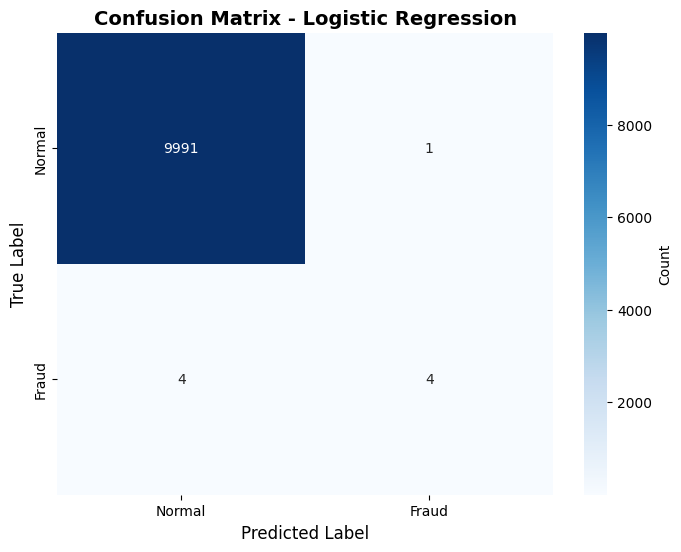

In [10]:
# Generate confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix (Logistic Regression):")
print(cm_lr)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fraud'], 
            yticklabels=['Normal', 'Fraud'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

## Step 10: Print Classification Report

In [11]:
# Print classification report (Precision, Recall, F1-score)
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Fraud']))


Classification Report (Logistic Regression):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9992
       Fraud       0.80      0.50      0.62         8

    accuracy                           1.00     10000
   macro avg       0.90      0.75      0.81     10000
weighted avg       1.00      1.00      1.00     10000



## Step 11: Train Random Forest Classifier

In [12]:
# Train Random Forest Classifier
print("Training Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully!")

# Make predictions on test data
y_pred_rf = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", f"{rf_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

Training Random Forest model...
Random Forest model trained successfully!
Random Forest Accuracy: 0.9997
Random Forest Accuracy: 99.97%


## Step 12: Evaluate Random Forest Model

Confusion Matrix (Random Forest):
[[9991    1]
 [   2    6]]


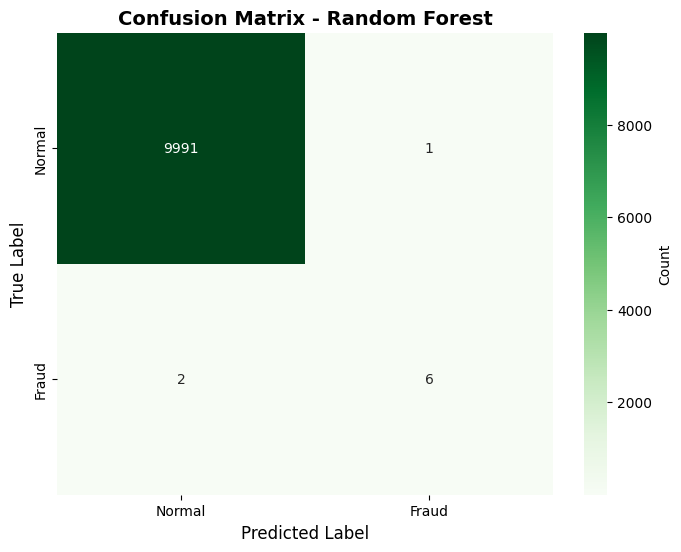


Classification Report (Random Forest):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9992
       Fraud       0.86      0.75      0.80         8

    accuracy                           1.00     10000
   macro avg       0.93      0.87      0.90     10000
weighted avg       1.00      1.00      1.00     10000



In [13]:
# Generate confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix (Random Forest):")
print(cm_rf)

# Plot confusion matrix as heatmap for Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Normal', 'Fraud'], 
            yticklabels=['Normal', 'Fraud'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

# Print classification report for Random Forest
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud']))

## Step 13: Compare Model Performance

MODEL PERFORMANCE COMPARISON
Logistic Regression Accuracy: 0.9995 (99.95%)
Random Forest Accuracy:       0.9997 (99.97%)
Difference:                   0.0002 (0.02%)

✓ Random Forest performs better by 0.02%


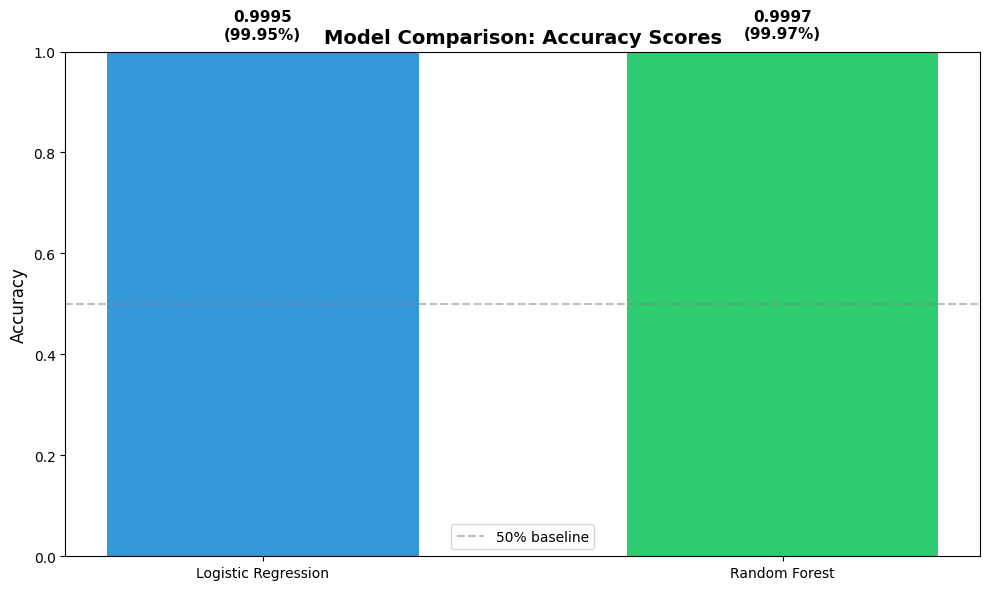

In [14]:
# Compare accuracies
print("="*50)
print("MODEL PERFORMANCE COMPARISON")
print("="*50)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f} ({lr_accuracy * 100:.2f}%)")
print(f"Random Forest Accuracy:       {rf_accuracy:.4f} ({rf_accuracy * 100:.2f}%)")
print(f"Difference:                   {abs(rf_accuracy - lr_accuracy):.4f} ({abs(rf_accuracy - lr_accuracy) * 100:.2f}%)")

if rf_accuracy > lr_accuracy:
    print(f"\n✓ Random Forest performs better by {(rf_accuracy - lr_accuracy) * 100:.2f}%")
else:
    print(f"\n✓ Logistic Regression performs better by {(lr_accuracy - rf_accuracy) * 100:.2f}%")
print("="*50)

# Create a comparison visualization
models = ['Logistic Regression', 'Random Forest']
accuracies = [lr_accuracy, rf_accuracy]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#3498db', '#2ecc71'], width=0.6)
plt.ylim([0, 1])
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Comparison: Accuracy Scores', fontsize=14, fontweight='bold')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% baseline')

# Add value labels on top of bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{acc:.4f}\n({acc*100:.2f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()


DETAILED METRICS COMPARISON: PRECISION, RECALL, F1-SCORE
Metric               Logistic Regression       Random Forest            
----------------------------------------------------------------------
Precision            0.9994                    0.9997                   
Recall               0.9995                    0.9997                   
F1-Score             0.9994                    0.9997                   


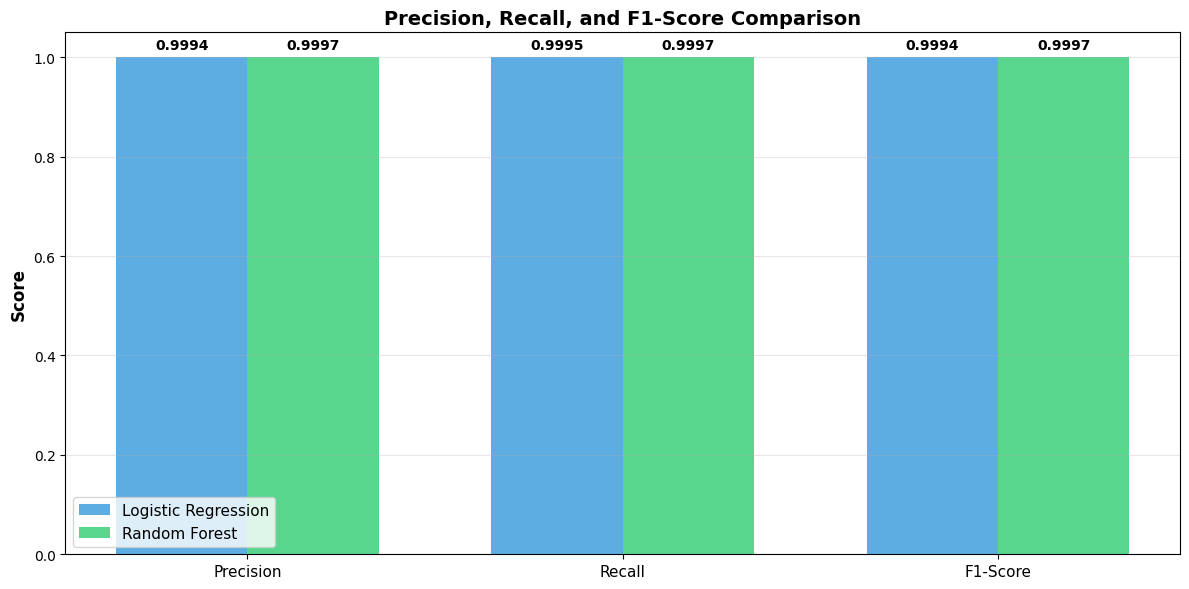


📊 Metrics Summary:
  • Precision: How many fraud predictions were correct
  • Recall: How many actual frauds were detected
  • F1-Score: Harmonic mean of Precision and Recall


In [15]:
# Extract and visualize Precision, Recall, F1-score metrics
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics for both models
lr_precision = precision_score(y_test, y_pred_lr, average='weighted')
lr_recall = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

# Create metrics comparison table
print("\n" + "="*70)
print("DETAILED METRICS COMPARISON: PRECISION, RECALL, F1-SCORE")
print("="*70)
print(f"{'Metric':<20} {'Logistic Regression':<25} {'Random Forest':<25}")
print("-"*70)
print(f"{'Precision':<20} {lr_precision:<25.4f} {rf_precision:<25.4f}")
print(f"{'Recall':<20} {lr_recall:<25.4f} {rf_recall:<25.4f}")
print(f"{'F1-Score':<20} {lr_f1:<25.4f} {rf_f1:<25.4f}")
print("="*70)

# Create visualization
metrics = ['Precision', 'Recall', 'F1-Score']
lr_values = [lr_precision, lr_recall, lr_f1]
rf_values = [rf_precision, rf_recall, rf_f1]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, lr_values, width, label='Logistic Regression', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, rf_values, width, label='Random Forest', color='#2ecc71', alpha=0.8)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Precision, Recall, and F1-Score Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Metrics Summary:")
print(f"  • Precision: How many fraud predictions were correct")
print(f"  • Recall: How many actual frauds were detected")
print(f"  • F1-Score: Harmonic mean of Precision and Recall")
